# 01 - Exploration du dataset

**Objectif de l'etape.** Charger la sequence d'images de la voiture, verifier l'ordre temporel des frames et observer la qualite generale. L'objet etudie est une voiture, donc un objet rigide dont le centre peut representer la trajectoire globale.

**Lien avec le sujet.** Le mouvement est estime entre frames successives: l'ordre des images est donc essentiel.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

DATASET_DIR = PROJECT_ROOT / 'data' / 'car' / 'car-11' / 'img'
RESULTS_DIR = PROJECT_ROOT / 'results'
RESULTS_DIR.mkdir(exist_ok=True)

image_files = sorted([p for p in DATASET_DIR.iterdir() if p.suffix.lower() in {'.jpg', '.jpeg', '.png'}])
print('Nombre de frames:', len(image_files))

Nombre de frames: 1661


In [2]:
import cv2
import matplotlib.pyplot as plt

first = cv2.imread(str(image_files[0])) if image_files else None
if first is None:
    raise RuntimeError('Aucune frame lisible.')
height, width = first.shape[:2]
print('Dimensions:', width, 'x', height)
print('Premiere frame:', image_files[0].name)
print('Derniere frame:', image_files[-1].name)

Dimensions: 1280 x 720
Premiere frame: 00000001.jpg
Derniere frame: 00001661.jpg


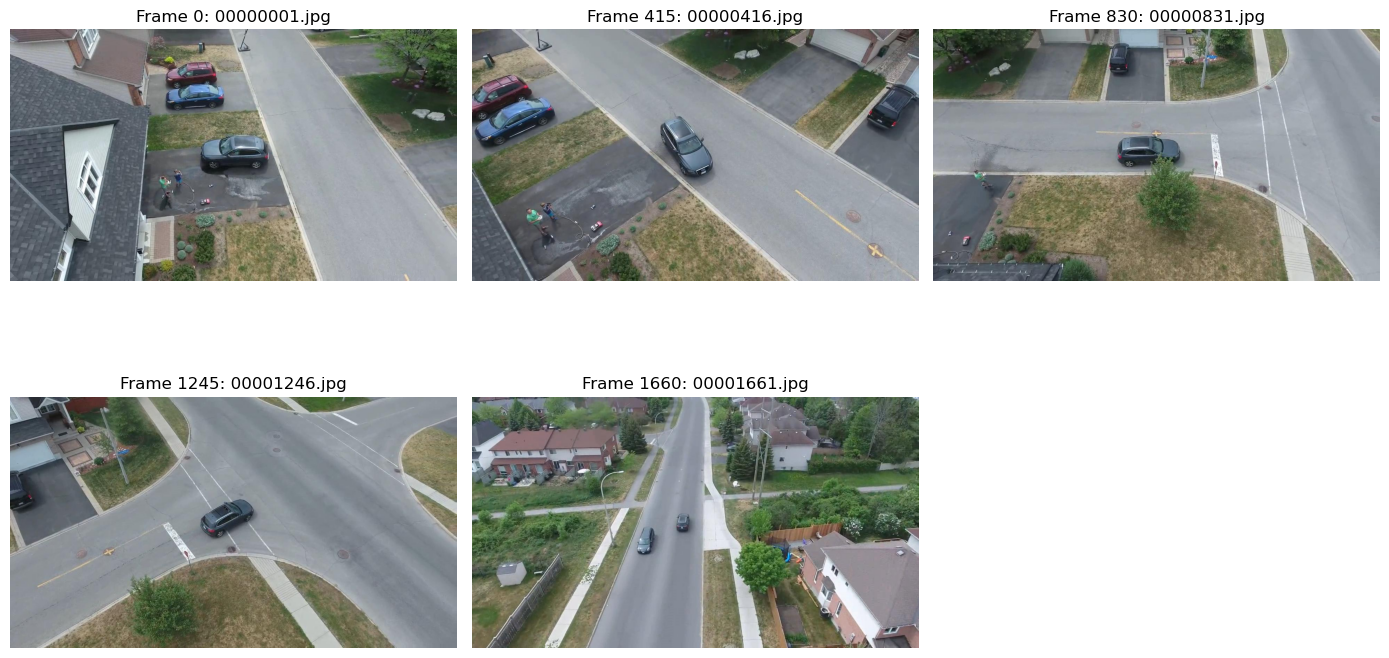

In [3]:
indices = [0, len(image_files)//4, len(image_files)//2, 3*len(image_files)//4, len(image_files)-1]
plt.figure(figsize=(14, 8))
for i, idx in enumerate(indices, start=1):
    frame = cv2.imread(str(image_files[idx]))
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    plt.subplot(2, 3, i)
    plt.imshow(frame_rgb)
    plt.title(f'Frame {idx}: {image_files[idx].name}')
    plt.axis('off')
plt.tight_layout()
plt.show()

**Resultats generes.** Cette etape affiche plusieurs frames et confirme le nombre total d'images ainsi que leurs dimensions.

**Interpretation.** La sequence montre une scene exterieure avec une voiture dont la position change au cours du temps. La qualite des images est suffisante pour appliquer des methodes classiques, mais l'eclairage, les ombres et la presence d'autres objets peuvent influencer les etapes suivantes.